In [1]:
import os, json, shutil
shutil.rmtree('__pycache__', ignore_errors=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize as MplNormalize
from index import SyntheticGenerator
from utils.index import *

In [2]:
best_options = {
    "layerRange": [
        26,
        233
    ],
    "layerThickness": [
        1,
        4
    ],
    "foldCount": [
        15,
        48
    ],
    "foldSigma": [
        17,
        57
    ],
    "foldAmplitude": [
        -35,
        5
    ],
    "foldDamping": 1.35,
    "foldBaseShift": [
        -0.75,
        4.45
    ],
    "shearOffset": [
        -8.68,
        3.3
    ],
    "shearGradient": [
        -0.1,
        0.02
    ],
    "faultCount": [
        0,
        10
    ],
    "faultThrow": [
        15,
        32
    ],
    "faultDipAngle": [
        55,
        81
    ],
    "faultRoughness": 3.54,
    "faultRoughSigma": 8.55,
    "faultDecaySigma": [
        49,
        59
    ],
    "faultZoneWidth": 0.99,
    "faultThreshold": 0.77,
    "faultCurveProb": 0.07,
    "faultCurveMax": 8.44,
    "waveletFreq": [
        72,
        99
    ],
    "waveletDuration": 0.1,
    "waveletDt": 0.0012,
    "noiseLevel": [
        0.001,
        0.620
    ]
}

# VISUALIZAÇÃO - 2D

showing img 0


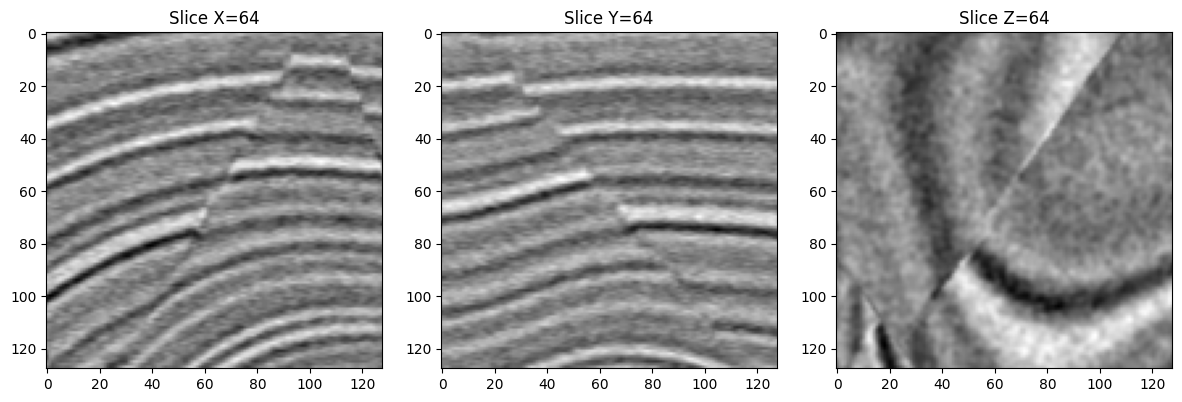

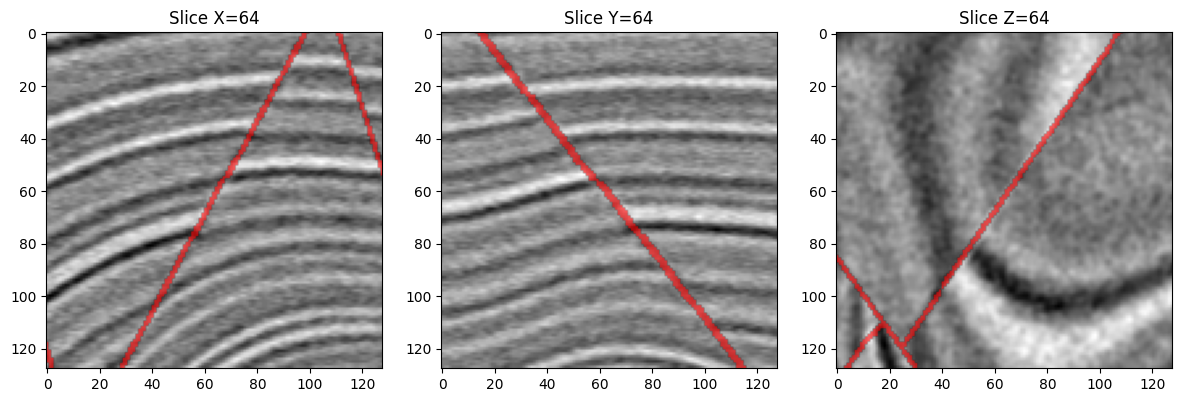




showing img 1


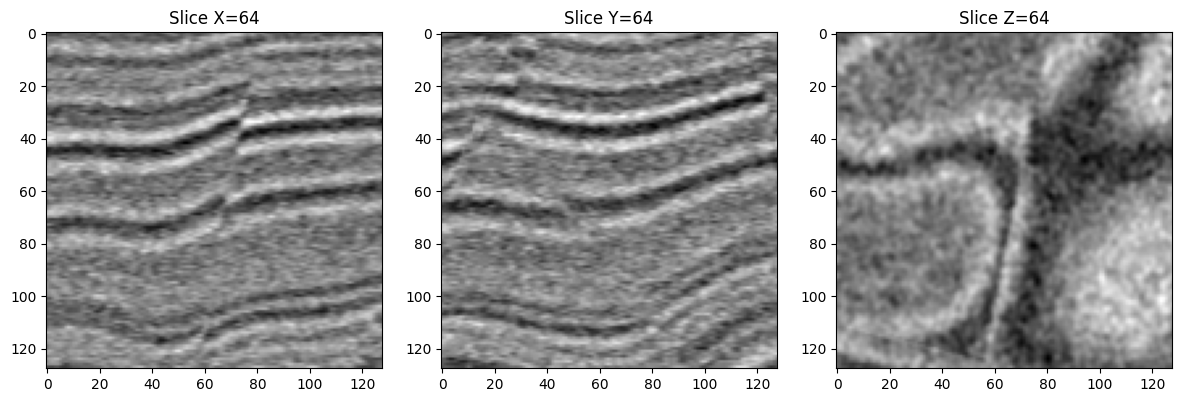

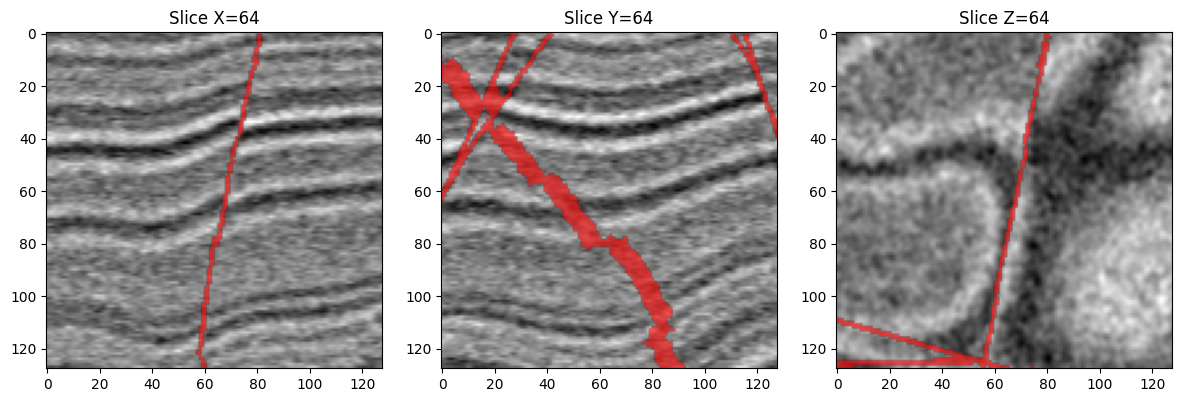




showing img 2


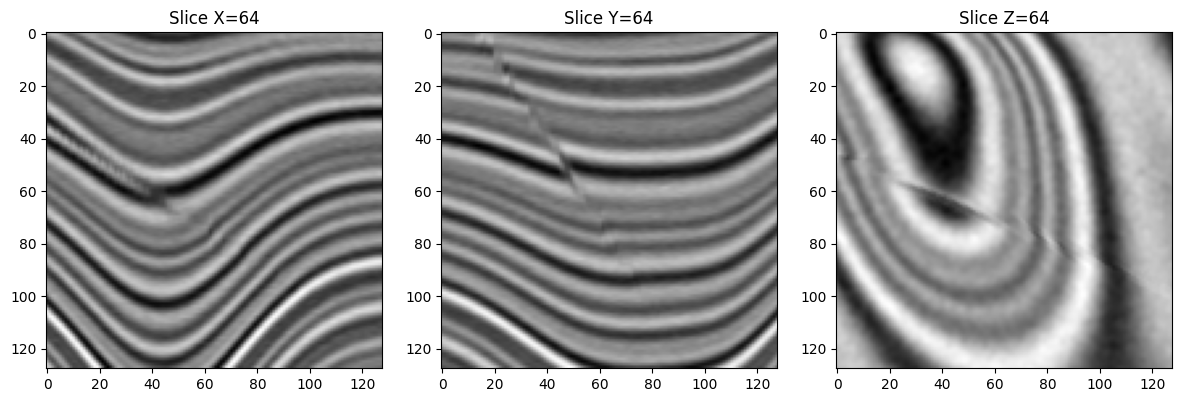

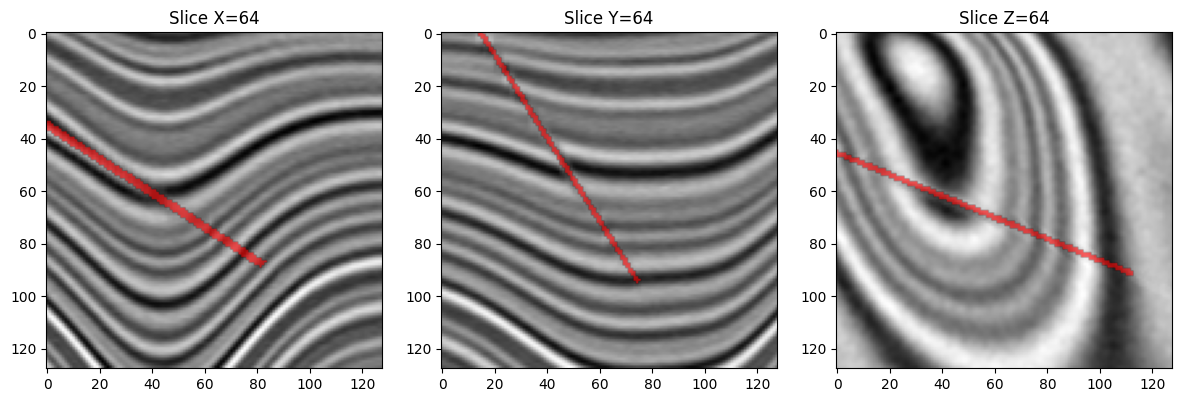




showing img 3


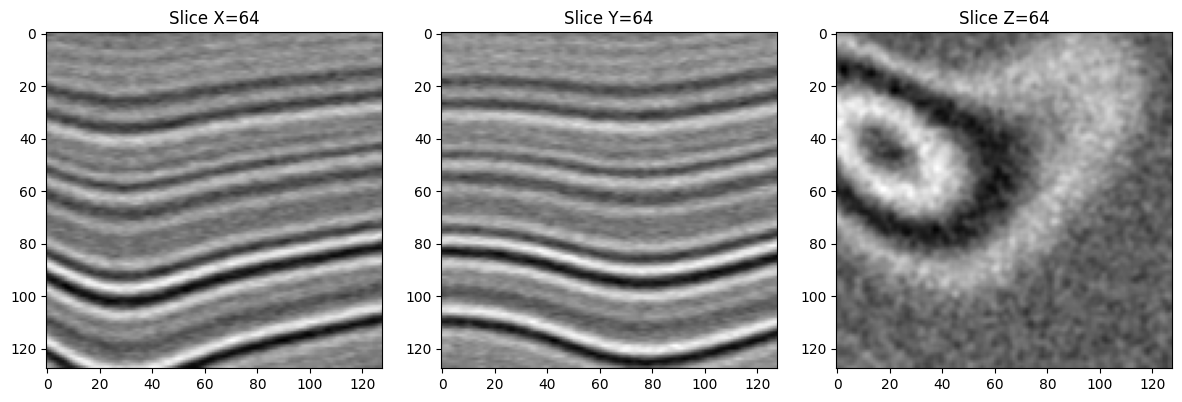

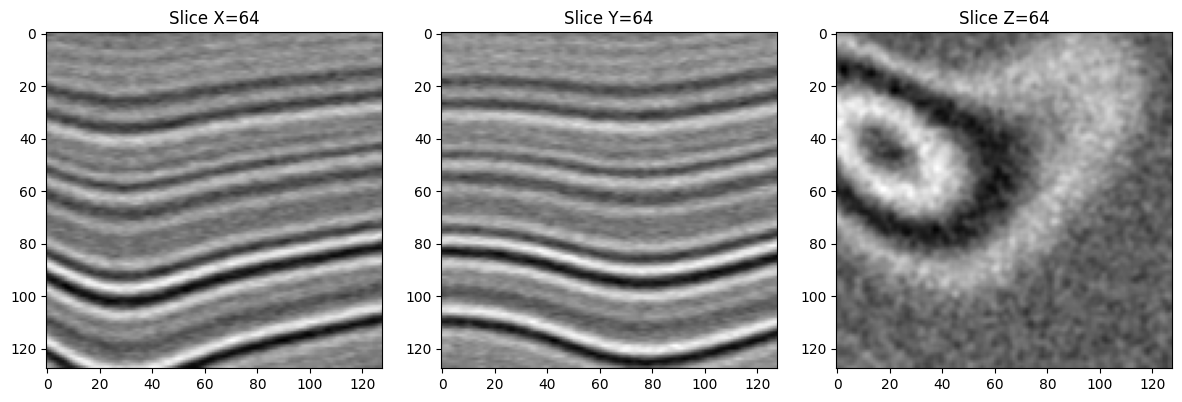




showing img 4


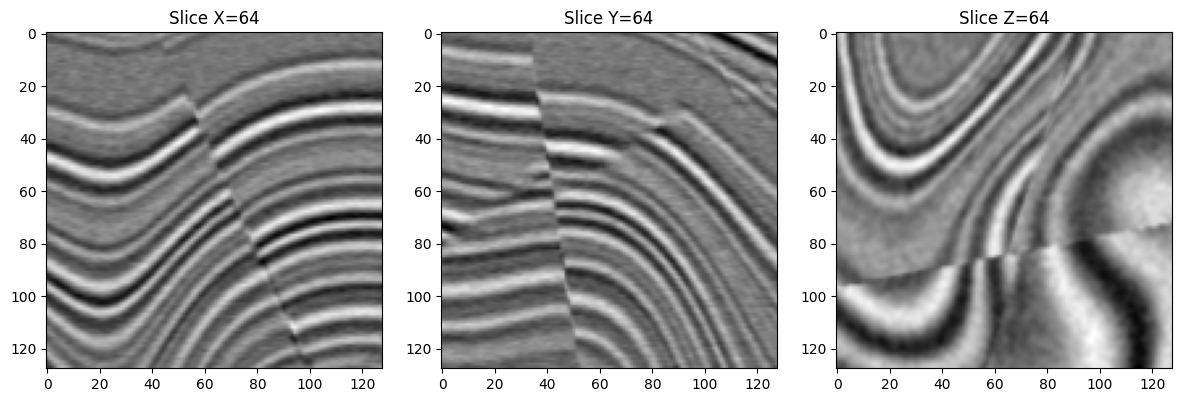

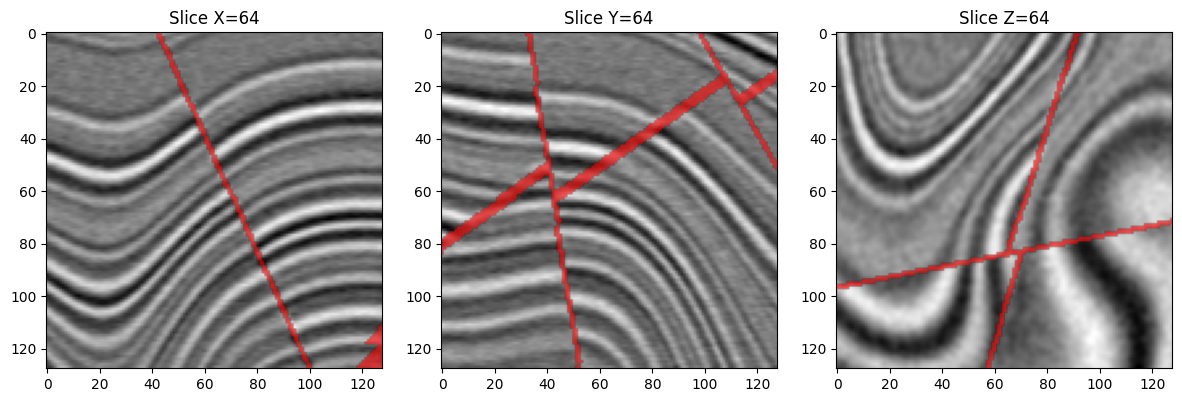

In [3]:
for i in range(5):
    gen = SyntheticGenerator()
    gen.set(best_options)

    print('showing img', i)
    image, mask = gen.get()    
    image, mask = formatAxis(image), formatAxis(mask)
    
    showTile(image)
    showTile(image, mask)
    print('\n\n')

# VISUALIZAÇÃO - 3D

In [4]:
def show3DCube(ax, volume, label, x_ratio=0.1, y_ratio=0.9, z_ratio=0.9, stride=1):
    nx, ny, nz = volume.shape
    pos_x, pos_y, pos_z = int(nx * x_ratio), int(ny * y_ratio), int(nz * z_ratio)
    cmap = plt.cm.gray
    norm = MplNormalize(vmin=volume.min(), vmax=volume.max())

    def plot_plane(axis_to_fix, fixed_pos):
        if axis_to_fix == 'y':    # Plano XZ
            ranges_dim1 = [(0, pos_x + 1), (pos_x, nx)]
            ranges_dim2 = [(0, pos_z + 1), (pos_z, nz)]
        elif axis_to_fix == 'x':  # Plano YZ
            ranges_dim1 = [(0, pos_y + 1), (pos_y, ny)]
            ranges_dim2 = [(0, pos_z + 1), (pos_z, nz)]
        else:                     # Plano XY (z)
            ranges_dim1 = [(0, pos_x + 1), (pos_x, nx)]
            ranges_dim2 = [(0, pos_y + 1), (pos_y, ny)]

        for start1, end1 in ranges_dim1:
            for start2, end2 in ranges_dim2:
                arr1, arr2 = np.arange(start1, end1), np.arange(start2, end2)

                if axis_to_fix == 'y':
                    X, Z = np.meshgrid(arr1, arr2, indexing='ij')
                    Y = np.full_like(X, fixed_pos)
                    Z_plot = nz - Z
                    data = volume[start1:end1, fixed_pos, start2:end2]
                elif axis_to_fix == 'x':
                    Y, Z = np.meshgrid(arr1, arr2, indexing='ij')
                    X = np.full_like(Y, fixed_pos)
                    Z_plot = nz - Z
                    data = volume[fixed_pos, start1:end1, start2:end2]
                else:
                    X, Y = np.meshgrid(arr1, arr2, indexing='ij')
                    Z_plot = np.full_like(X, nz - fixed_pos)
                    data = volume[start1:end1, start2:end2, fixed_pos]

                ax.plot_surface(X, Y, Z_plot, facecolors=cmap(norm(data)), shade=False, antialiased=False, linewidth=0, rstride=stride, cstride=stride)

    plot_plane('y', pos_y) # Parede XZ
    plot_plane('x', pos_x) # Parede YZ
    plot_plane('z', pos_z) # Chão XY
    ax.set_xlim(0, nx); ax.set_ylim(0, ny); ax.set_zlim(0, nz)
    ax.set_box_aspect([1, 1, 1]); ax.set_axis_off()
    ax.set_title(label, fontsize=14, fontweight='bold', loc='left')
    ax.view_init(elev=20, azim=-45)

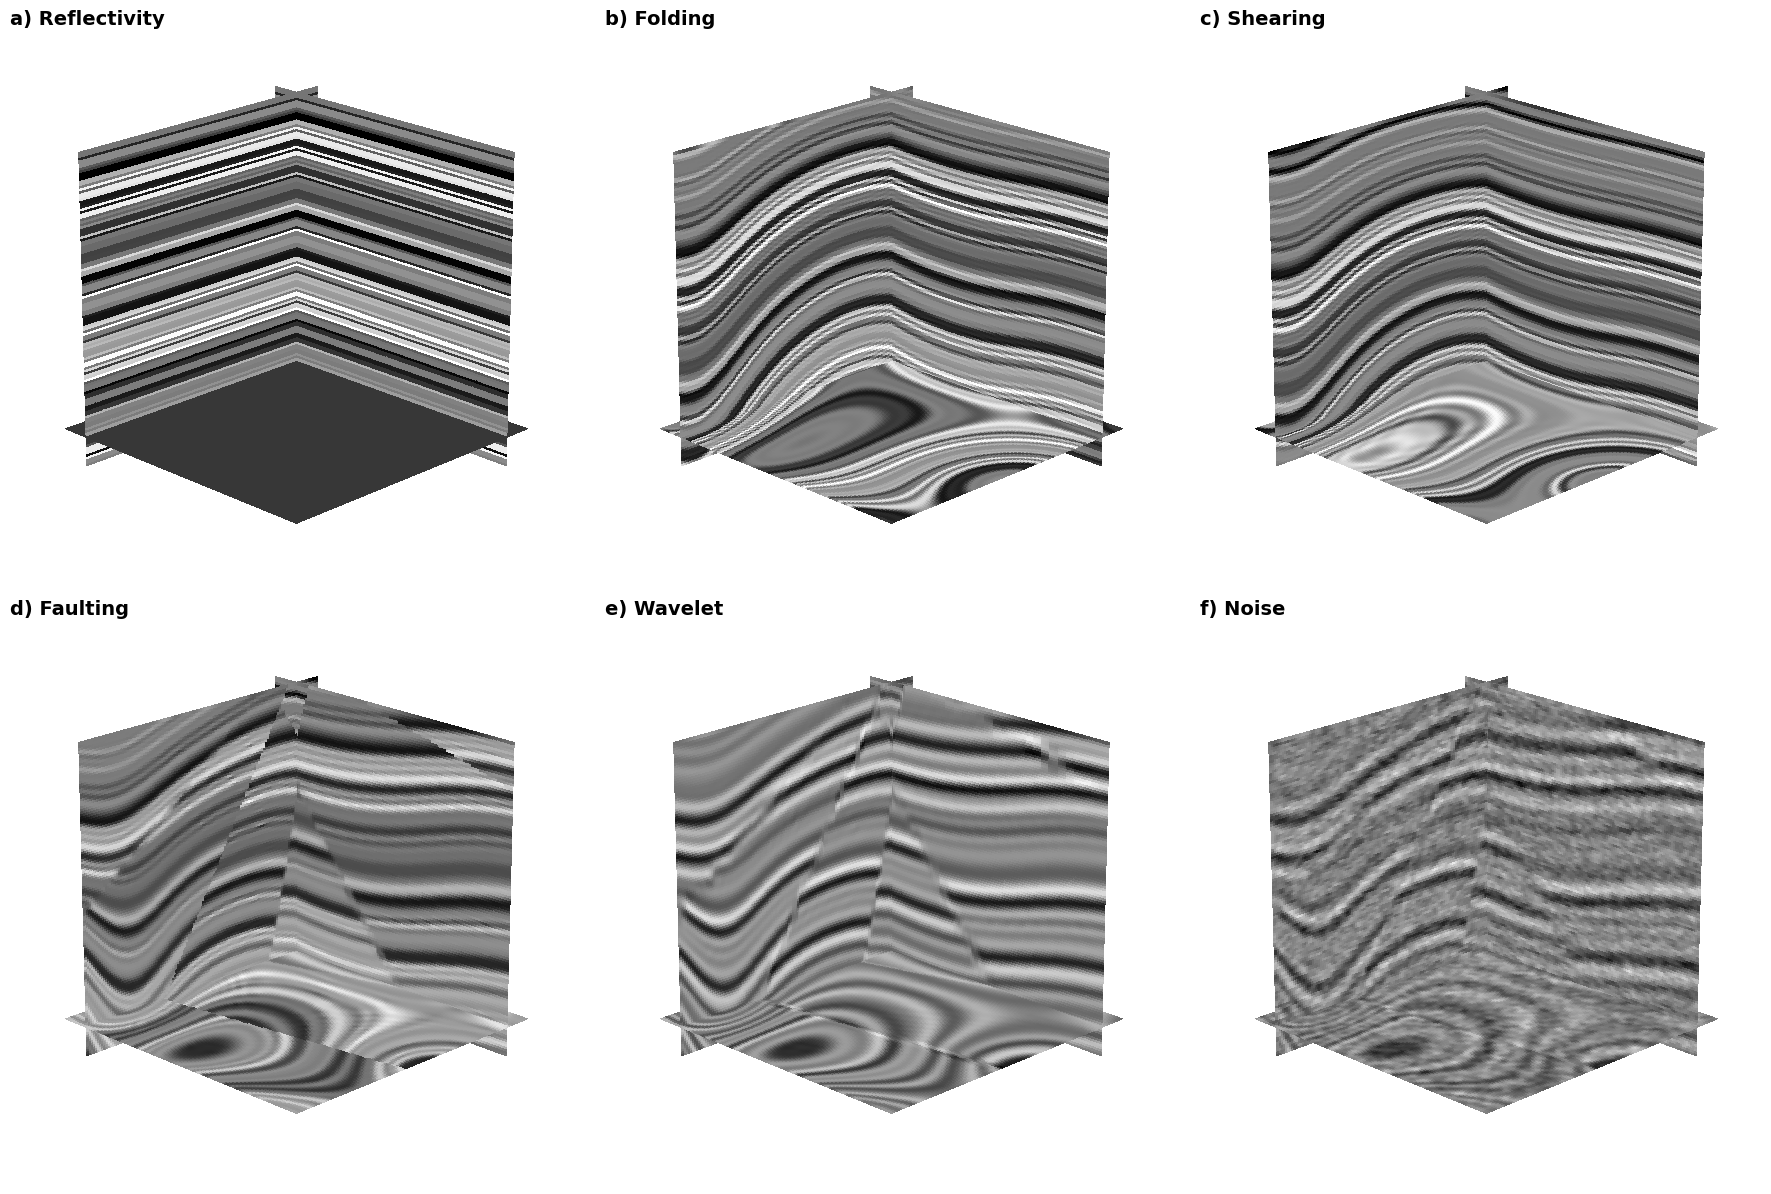

In [ ]:
for i in range(2):
    gen = SyntheticGenerator()
    gen.set(best_options)

    reflectivity = gen.genReflectivity()
    folded  = gen.applyFolding(reflectivity)
    sheared = gen.applyShearing(folded)
    faulted, mask = gen.applyFaulting(sheared)
    seismic = gen.applyWavelet(faulted)
    noisy   = gen.applyNoise(seismic)
    steps   = [
        (gen.crop(np.broadcast_to(reflectivity, gen.shape)), 'a) Reflectivity'),
        (gen.crop(folded),       'b) Folding'),
        (gen.crop(sheared),      'c) Shearing'),
        (gen.crop(faulted),      'd) Faulting'),
        (gen.crop(seismic),      'e) Wavelet'),
        (gen.crop(noisy),        'f) Noise'),
    ]
    fig = plt.figure(figsize=(18, 12))
    for i, (volume, label) in enumerate(steps):
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        show3DCube(ax, volume, label)
    plt.tight_layout()
    plt.show()

# APLICANDO DATASET

In [ ]:
SAVE_DATA = False
dataset   = 'dataset_74_2000'
os.makedirs(f'../Dataset/{dataset}/', exist_ok=True)

with open(f'../Dataset/{dataset}/synthetic.json', 'w', encoding='utf-8') as file:
    json.dump(best_options, file, ensure_ascii=False, indent=4)

options = {
    'directory': f'../Dataset/{dataset}',
    'regions': {
        'original': {
            'n_images': 2000, 
            'output': 'original',
            'params': best_options
        }
    }
}

if SAVE_DATA:
    gen = SyntheticGenerator(seed=42)
    gen.set(best_options)
    gen.dataset(options)